In [18]:
from pathlib import Path
import numpy as np
from typing import Callable
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
%matplotlib inline

from flowing import flowtime_to_radius, radius_to_flowtime
from measurements import *

Some general info:
- dimension of lattice $n_t \times n_s^3$
- list of flowtimes $t_i / a^2$
- local_tol used in generating flowtime list using adaptive stepsize algorithm
- flow type of gradient flow

In [19]:
ns = 64
nt = 16

flowtimes = np.array([ 0.02572923590301565, 0.05303278154520656, 0.08103495224784385, 0.110208782326772, 0.141058391298962, 0.1736893835495303,
                       0.2086835114617738, 0.2454549361253429, 0.2838117228448263, 0.3249152519239425, 0.3705101434001126, 0.4179449298122797,
                       0.4696233239687699, 0.5279559816139976, 0.5890993819917063, 0.6570215111572449, 0.734680305158274, 0.8257738792221512,
                       0.9353328035912798, 1.06959076807306, 1.233820281085228, 1.435936459574629 ], dtype=float)#, 1.68034447439404, 1.972161672512587 ]

local_tol = 3.00e-04    # flowtimes based on this (not used here)
flow_type = 'zeuthen'   # just for information, prabably not needed

Loading of correlation data for each ensemble, then computing sample means and standart deviations

In [20]:
# load in correlation ensemble data
home_path = Path('/home/ln29bamu')
code_path = home_path / 'code' / 'milc_luis'

skip_configs = 50
all_corrs = np.load(code_path / 'zeugs' / 'outputs' / '16x64flows' / 'data0.npy')[skip_configs::10]
print(all_corrs.shape, all_corrs.dtype)

# numbers of configs, flowtimes, time and spatial separations
n_cofigs, n_flows, n_tau, n_r = all_corrs.shape
print(f'\n{n_cofigs = }\n{n_flows  = }\n{n_tau    = }\n{n_r      = }')

# list of all spatial separations, list of multiplicities of each spatial separation
r_list  = np.array(radial_separations(ns), dtype=float)
dr_list = np.array(make_distance_corr_arrays(radial_multiplicities(ns), False), dtype=float)

# sample mean, sample std, std of sample mean
avg_corrs = all_corrs.mean(axis=0)              # sample mean
std_corrs = all_corrs.std(axis=0, ddof=1)       # sample standart deviation
sem_corrs = std_corrs / np.sqrt(n_cofigs)       # standart deviation of sample mean


(101, 22, 9, 1914) float64

n_cofigs = 101
n_flows  = 22
n_tau    = 9
n_r      = 1914


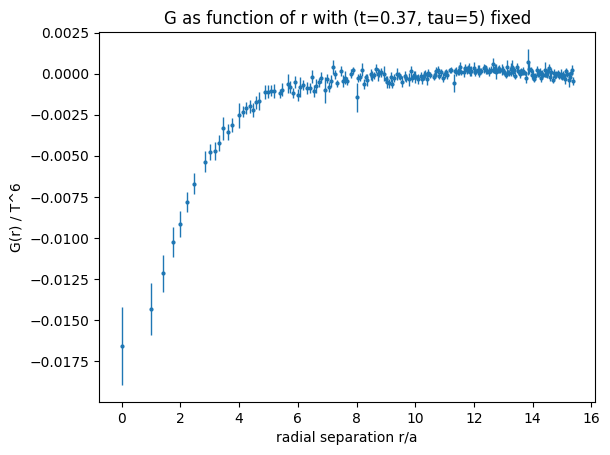

In [21]:
iflow = 10
tau   = 5

ir_max = 200

plt.errorbar(
    x          = r_list[:ir_max],
    y          = avg_corrs[iflow, tau, :ir_max],
    yerr       = sem_corrs[iflow, tau, :ir_max],
    marker     = 'o',
    markersize = 2,
    linestyle  = 'none',
    linewidth  = 1,
    label      = f't={flowtimes[iflow]:.2f}'
)
plt.xlabel('radial separation r/a')
plt.ylabel('G(r) / T^6')
# plt.legend()
plt.title(f'G as function of r with (t={flowtimes[iflow]:.2f}, tau={tau}) fixed')
plt.show()

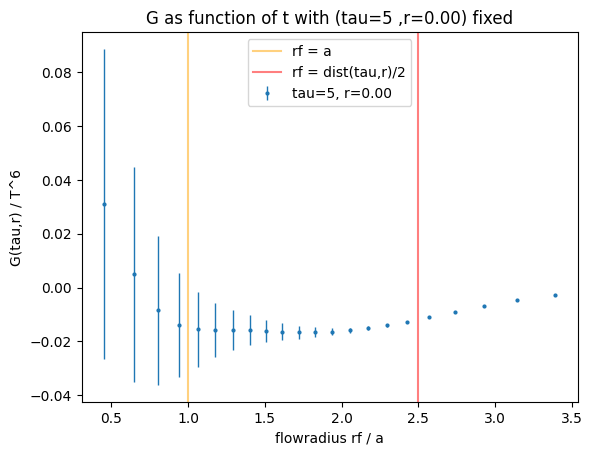

In [22]:
tau = 5
ir  = 0

plt.errorbar(
    # x          = flowtimes,
    x          = [flowtime_to_radius(ft, nt) * nt for ft in flowtimes],
    y          = avg_corrs[:, tau, ir],
    yerr       = sem_corrs[:, tau, ir],
    marker     = 'o',
    markersize = 2,
    linestyle  = 'none',
    linewidth  = 1,
    label      = f'tau={tau}, r={r_list[ir]:.2f}'
)
plt.xlabel('flowradius rf / a')
plt.ylabel('G(tau,r) / T^6')

# t_min = radius_to_flowtime(1/nt, nt)
# t_max = radius_to_flowtime((tau**2 + r_list[ir]**2)**.5 / 2 / nt, nt)
t_min = 1
t_max = (tau**2 + r_list[ir]**2)**.5 / 2
plt.axvline(x=t_min, alpha=0.5, color='orange', label='rf = a')
plt.axvline(x=t_max, alpha=0.5, color='red',    label='rf = dist(tau,r)/2')

plt.legend()
plt.title(f'G as function of t with (tau={tau} ,r={r_list[ir]:.2f}) fixed')
plt.show()

for above:
- think about t_min and t_max that incorporate extended operator due to imrpoved clover terms (induces contact terms)
- compare to larger distances (tau, r)


Goal: Doing the sum $\quad G_t(\tau) = \sum_r G_t(\tau, r)$

First: Naive sum
- do partial sum as a function of $r$-cutoff
- include correlations between $r$-values


(1914, 1914) float64


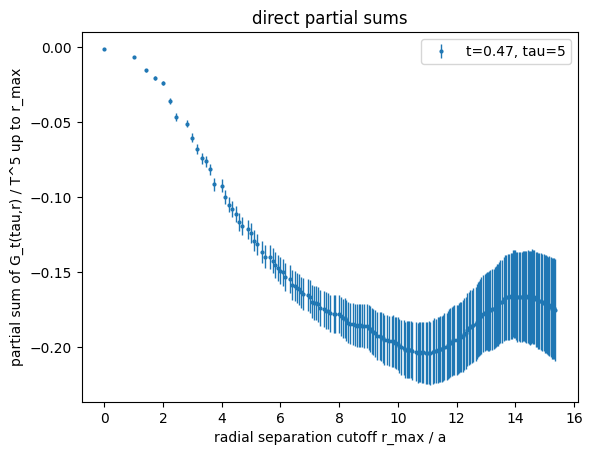

In [23]:
iflow = 12
tau   = 5

covmat = np.cov(all_corrs[:, iflow, tau, :], rowvar=False) / n_cofigs
covmat_dr = covmat * np.outer(dr_list, dr_list)
print(covmat_dr.shape, covmat_dr.dtype)


partial_sums     = np.empty(shape=(n_r,), dtype=float)
partial_sums_var = np.empty(shape=(n_r,), dtype=float)

for ir in range(n_r):
    partial_sums[ir]     = (avg_corrs * dr_list)[iflow, tau, :ir+1].sum()
    partial_sums_var[ir] = covmat_dr[:ir+1, :ir+1].sum()

# should have units T^5 and not T^6
partial_sums /= nt
partial_sums_var /= nt**2


r_cut = 200
plt.errorbar(
    x = r_list[:r_cut],
    y = partial_sums[:r_cut],
    yerr = np.sqrt(partial_sums_var)[:r_cut],
    marker     = 'o',
    markersize = 2,
    linestyle  = 'none',
    linewidth  = 1,
    label      = f't={flowtimes[iflow]:.2f}, tau={tau}'
)
plt.xlabel('radial separation cutoff r_max / a')
plt.ylabel('partial sum of G_t(tau,r) / T^5 up to r_max')

plt.legend()
plt.title('direct partial sums')
plt.show()

- now test at which $r$ the $s/n$ is always worse than some value, like $10$
- then plot $s/n$ over $r$, with line marked after which always $s/n < 10$
- same with $G_t(\tau,r)$ over $r$

(22, 9, 1914) float64
sn_min = 5: ir = 26, r = 5.48
sn_min = 4.5: ir = 32, r = 6.08


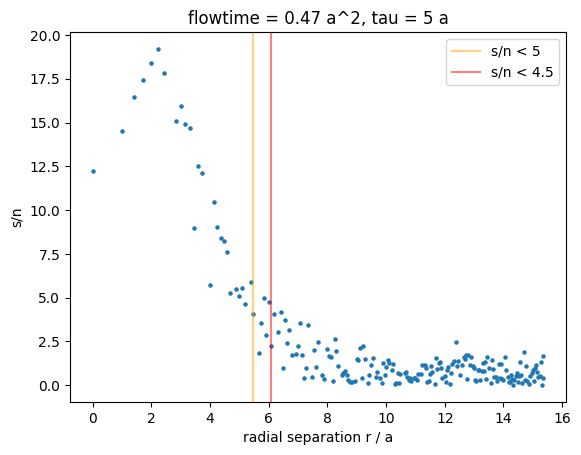

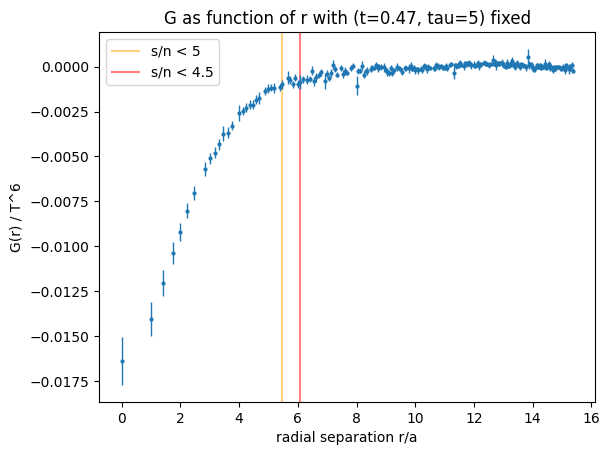

In [24]:
signal_to_noise = np.abs(avg_corrs / sem_corrs)
print(signal_to_noise.shape, signal_to_noise.dtype)



def find_sn_cutoff(iflow : int, tau : int, sn_min : float) -> int|None:
    '''find index of r, such that s/n < sn_min for all r' >= r. (None if no such index exists)'''
    i_cand = None
    for ir, sn in enumerate(signal_to_noise[iflow, tau, :]):
        if   i_cand is None     and sn <  sn_min: i_cand = ir
        elif i_cand is not None and sn >= sn_min: i_cand = None
    return i_cand

sn0 = 5
ir_sn0 = find_sn_cutoff(iflow, tau, sn0)
print(f'sn_min = {sn0}: ir = {ir_sn0}, r = {r_list[ir_sn0]:.2f}')

sn1 = 4.5
ir_sn1 = find_sn_cutoff(iflow, tau, sn1)
print(f'sn_min = {sn1}: ir = {ir_sn1}, r = {r_list[ir_sn1]:.2f}')



plt.axvline(x=r_list[ir_sn0], alpha=0.5, color='orange', label=f's/n < {sn0}')
plt.axvline(x=r_list[ir_sn1], alpha=0.5, color='red',    label=f's/n < {sn1}')

plt.scatter(
    x      = r_list[:r_cut],
    y      = signal_to_noise[iflow, tau, :r_cut],
    marker = 'o',
    s      = 5,
)
plt.xlabel('radial separation r / a')
plt.ylabel('s/n')

plt.legend()
plt.title(f'flowtime = {flowtimes[iflow]:.2f} a^2, tau = {tau} a')
plt.show()
plt.close()



plt.axvline(x=r_list[ir_sn0], alpha=0.5, color='orange', label=f's/n < {sn0}')
plt.axvline(x=r_list[ir_sn1], alpha=0.5, color='red',    label=f's/n < {sn1}')

plt.errorbar(
    x          = r_list[:r_cut],
    y          = avg_corrs[iflow, tau, :r_cut],
    yerr       = sem_corrs[iflow, tau, :r_cut],
    marker     = 'o',
    markersize = 2,
    linestyle  = 'none',
    linewidth  = 1,
)
plt.xlabel('radial separation r/a')
plt.ylabel('G(r) / T^6')
plt.legend()
plt.title(f'G as function of r with (t={flowtimes[iflow]:.2f}, tau={tau}) fixed')
plt.show()

A = -1.42e-02 pm 5.77e-03, B = 2.83 pm 0.37
[[ 3.33344493e-05 -2.10848175e-03]
 [-2.10848175e-03  1.36014223e-01]]


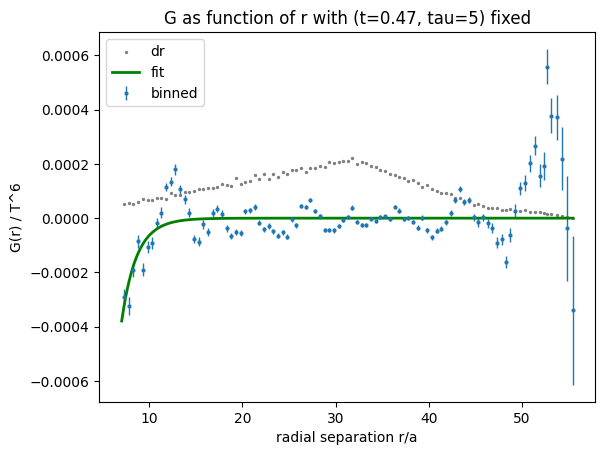

In [31]:
iflow = 12
tau   = 5

# fitting function
def exp_fit(r_pivot : float) -> Callable[[float, float, float], float]:
    return lambda r,A,B: A*(r/r_pivot)**(-1) * np.exp(-B * (r/r_pivot))

r_pivot = r_list[ir_sn0 + 3]
fit_fct = exp_fit(r_pivot)

(A, B), fitcov = curve_fit(
    f = fit_fct,
    xdata = r_list[ir_sn0:ir_sn1*5],
    ydata = avg_corrs[iflow, tau, ir_sn0:ir_sn1*5],
    p0 = (-1, 4),
    # sigma = np.cov(all_corrs[:, iflow, tau, ir_sn0:ir_sn1*5], rowvar=False)
)
dA, dB = np.sqrt(np.diag(fitcov))
print(f'A = {A:.2e} pm {dA:.2e}, B = {B:.2f} pm {dB:.2f}')
print(fitcov)


# plt.axvline(x=r_list[ir_sn0], alpha=0.5, color='orange', label=f's/n < {sn0}')
# plt.axvline(x=r_list[ir_sn1], alpha=0.5, color='red',    label=f's/n < {sn1}')

ir_left  = min(i for i in range(n_r) if r_list[i]>7)
ir_right = n_r

# plt.errorbar(
#     x          = r_list[ir_left:-1],
#     y          = avg_corrs[iflow, tau, ir_left:-1],
#     yerr       = sem_corrs[iflow, tau, ir_left:-1],
#     marker     = 'o',
#     markersize = 2,
#     linestyle  = 'none',
#     linewidth  = 1,
#     alpha      = 0.7,
#     label      = 'data'
# )
plt.errorbar(
    x          = r_list[ir_left:ir_right],
    y          = fit_fct(r_list[ir_left:ir_right], A, B),
    # yerr       = sem_corrs[iflow, tau, ir_left:ir_right],
    linestyle  = '-',
    linewidth  = 2,
    color      = 'green',
    label      = 'fit'
)


x_bin, y_bin, yerr_bin = bin_by_distance2(
    r_list[ir_left:ir_right],
    avg_corrs[iflow, tau, ir_left:ir_right],
    np.cov(all_corrs[:, iflow, tau, ir_left:ir_right], rowvar=False) / (ir_right-ir_left),
    0.5
)
plt.errorbar(
    x = x_bin,
    y = y_bin,
    yerr = yerr_bin,
    marker = 'o',
    markersize = 2,
    linestyle = 'none',
    linewidth  = 1,
    label = 'binned'
)

r_bin, dr_bin = bin_by_distance2(
    r_list[ir_left:ir_right],
    dr_list[ir_left:ir_right],
    None,
    0.5
)
plt.scatter(
    x = r_bin,
    y = dr_bin * 9e-7,
    marker = 'o',
    s = 2,
    label = 'dr',
    color = 'grey'
)


plt.xlabel('radial separation r/a')
plt.ylabel('G(r) / T^6')
plt.legend()
plt.title(f'G as function of r with (t={flowtimes[iflow]:.2f}, tau={tau}) fixed')
plt.show()


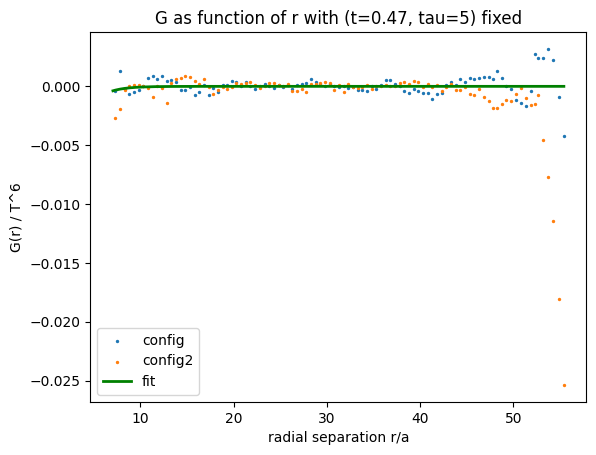

In [38]:
config = 66

x_bin, y_bin = bin_by_distance2(
    r_list[ir_left:ir_right],
    all_corrs[config, iflow, tau, ir_left:ir_right],
    None,
    0.5
)

plt.scatter(
    x = x_bin,
    y = y_bin,
    s = 2,
    label = 'config'
)

x_bin, y_bin = bin_by_distance2(
    r_list[ir_left:ir_right],
    all_corrs[config+3, iflow, tau, ir_left:ir_right],
    None,
    0.5
)
plt.scatter(
    x = x_bin,
    y = y_bin,
    s = 2,
    label = 'config2'
)

plt.errorbar(
    x          = r_list[ir_left:ir_right],
    y          = fit_fct(r_list[ir_left:ir_right], A, B),
    # yerr       = sem_corrs[iflow, tau, ir_left:ir_right],
    linestyle  = '-',
    linewidth  = 2,
    color      = 'green',
    label      = 'fit'
)

plt.xlabel('radial separation r/a')
plt.ylabel('G(r) / T^6')
plt.legend()
plt.title(f'G as function of r with (t={flowtimes[iflow]:.2f}, tau={tau}) fixed')
plt.show()

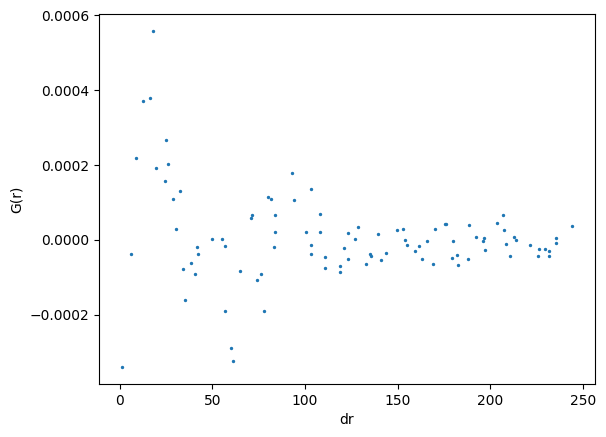

In [32]:
plt.scatter(
    x = dr_bin,
    y = y_bin,
    s = 2
)
plt.xlabel('dr')
plt.ylabel('G(r)')
plt.show()